In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [ ]:
df = pd.read_csv('netflix.csv')


## 1. Problem Statement and Basic Metrics
Netflix is one of the world's largest streaming platforms, offering thousands of movies and TV shows across different countries and genres. This analysis explores the Netflix content dataset to understand patterns in content type, genre popularity, country-wise content availability, and release trends — with the goal of helping Netflix decide what type of content to produce next and how to grow in different markets.


In [ ]:
a=df.shape
print(f'Number of rows in dataset are: {a[0]}')
print(f'Number of columns in dataset are: {a[1]}')
df.head()

Number of rows in dataset are: 8807
Number of columns in dataset are: 12


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


The dataset contains 8,807 rows and 12 columns, where each row represents a single movie or TV show on Netflix, with details on cast, director, country, category (listed_in), and release information.

## 2. Data Overview

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


The dataset contains 8,807 records across 12 columns. Most columns are text-based, while release_year is the only numeric column. Several columns have missing values: director is missing in 2,634 rows (30%), cast in 825 rows (9%), and country in 831 rows (9%) — significant enough that they'll need careful handling rather than simply dropping. date_added, rating, and duration have negligible missing values (10, 4, and 3 respectively). Since date_added is stored as text rather than a date, it needs to be converted for any time-based analysis.

In [ ]:
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')
categorical_cols = ['type', 'rating']
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [ ]:
df.describe()

,date_added,release_year
count,8709,8807.000000
mean,2019-05-23 01:45:29.452290816,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-20 00:00:00,2013.000000
50%,2019-07-12 00:00:00,2017.000000
75%,2020-08-26 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


The release_year column ranges from 1925 to 2021, showing that Netflix's catalog includes content spanning nearly a century. This wide range suggests the platform carries some older/classic titles alongside its primary focus on modern content — this will be explored further in the univariate analysis to see whether older titles are rare outliers or a meaningful part of the catalog.


In [ ]:
df.nunique()

,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1699
release_year,74
rating,17
duration,220


The high number of unique countries is unusual for a column that should represent nation names — this likely means many entries contain multiple countries combined in a single cell (e.g. "United States, India"), which we'll need to split apart during pre-processing. Similarly, the high director count reflects the fact that many rows list multiple directors together rather than one per row. rating having only 17 unique values makes sense, since it's a small standardized set of content ratings (TV-MA, PG-13, R, etc.).

In [ ]:
print(df['country'].dropna().str.contains(',').sum())

1320


## 3. Non-Graphical Analysis

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


Netflix's catalog is heavily skewed towards movies with 6131 movies and 2676 shows with a ratio of 70:30 split.It will be worth checking later that whether this balance has shifted in recent years or not.

In [ ]:
df['rating'].value_counts().head(3)

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863


This shows that netflix catalog is mainly leaned towards adult and teen appropriate content as tv-ma and tv-14 alone account for 60% of all titles.

Since country, director, cast, and listed_in contain multiple comma-separated values per row, we split them into individual values before analyzing them further — otherwise counts and plots for these columns would be misleading

## 4. Pre-processing

In [ ]:
df_country = df.assign(country=df['country'].str.split(',')).explode('country')
df_country['country'] = df_country['country'].str.strip()

In [ ]:
df_country['country'].value_counts().head(10)

,count
country,
United States,3690
India,1046
United Kingdom,806
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


After splitting it shows that netflix content production is largely focused in United States with 3690 titles followed by India with 1046 titles.It means that despite netflix global reach still it is heavily US centric.

In [ ]:
df_director = df.assign(director=df['director'].str.split(',')).explode('director')
df_director['director'] = df_director['director'].str.strip()

df_cast = df.assign(cast=df['cast'].str.split(',')).explode('cast')
df_cast['cast'] = df_cast['cast'].str.strip()

df_genre = df.assign(listed_in=df['listed_in'].str.split(',')).explode('listed_in')
df_genre['listed_in'] = df_genre['listed_in'].str.strip()


In [ ]:
df_genre['listed_in'].value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


After splitting it shows that International movies and dramas are clearly the top genres on Netflix followed by comedies.

### 4.1 Univariate Analysis

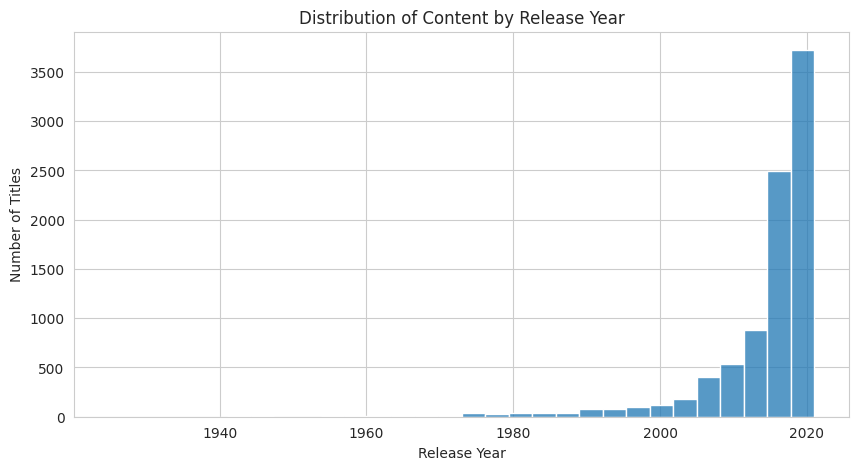

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'], bins=30)
plt.title('Distribution of Content by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

The distribution is heavily right-skewed toward recent years — the vast majority of titles were released after 2010, with a sharp spike between 2018 and 2020, where the count jumps to over 3,500 titles in the most recent bin. Content from before 1980 is negligible, appearing as a nearly flat line near zero. This confirms that while the catalog technically spans back to 1925, older titles are rare outliers rather than a meaningful part of the collection — Netflix's content is overwhelmingly modern, and the platform has aggressively ramped up content additions especially from 2015 onward."

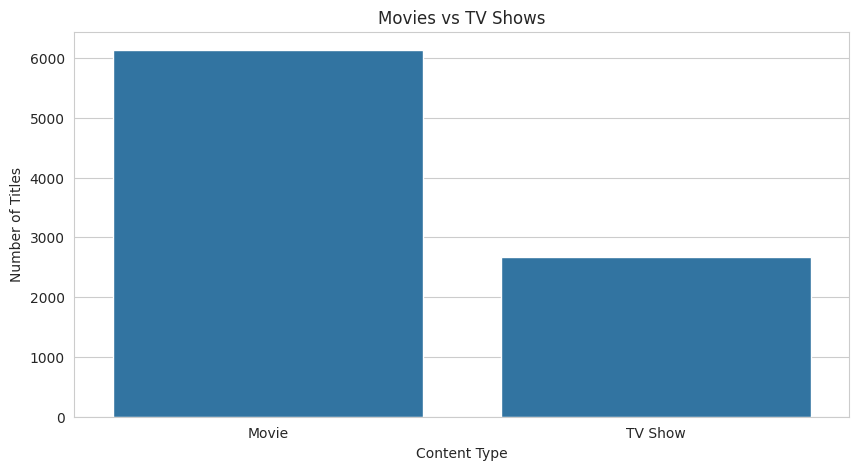

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='type')
plt.title('Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.show()

As we seen before that Netflix catalog is mainly focused on movies with 70/30 split.Lets see in further bivariate analysis that does this ratio shifting over time or not.

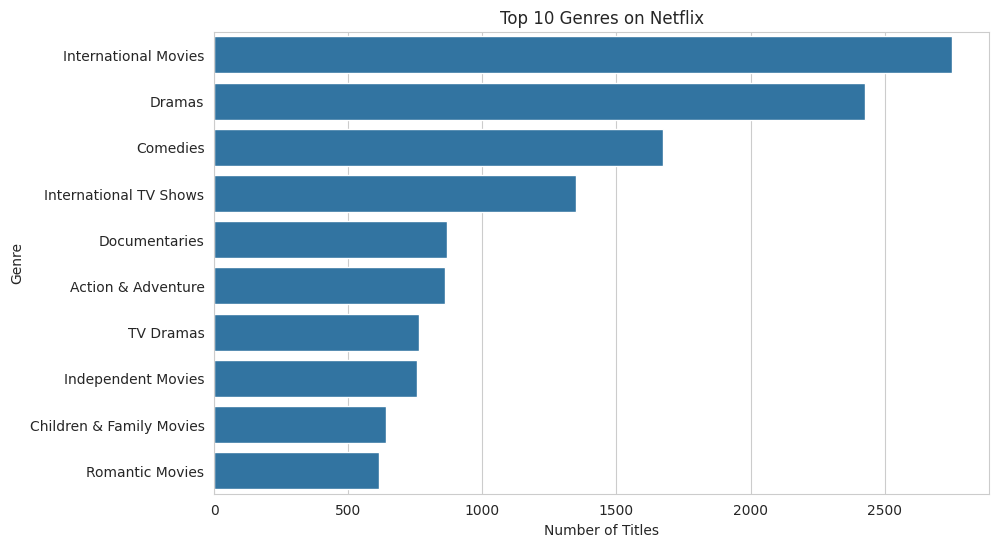

In [ ]:
plt.figure(figsize=(10,6))
top_genres = df_genre['listed_in'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

This visually confirms the genre distribution seen earlier — International Movies and Dramas lead the catalog.

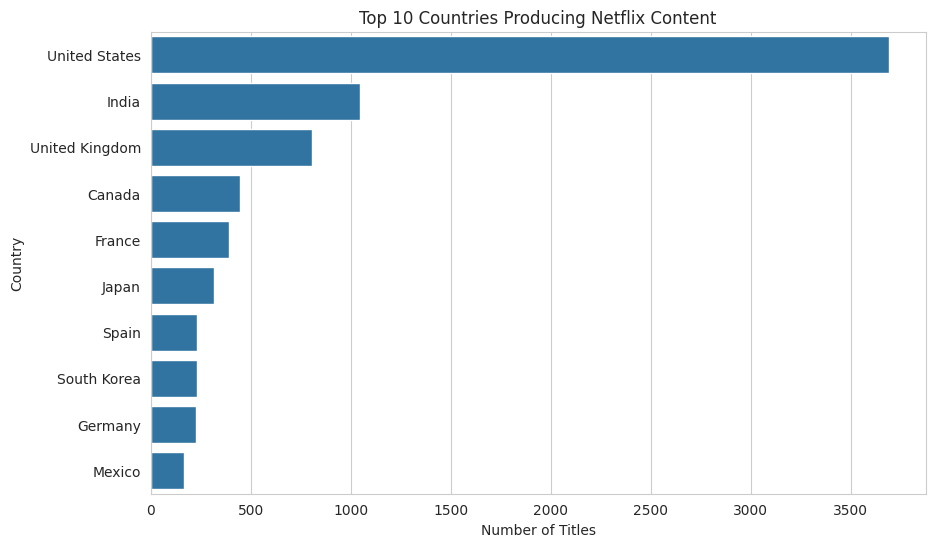

In [ ]:
plt.figure(figsize=(10,6))
top_countries = df_country['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

This visually confirms the country distribution seen earlier — the US and India lead content production.

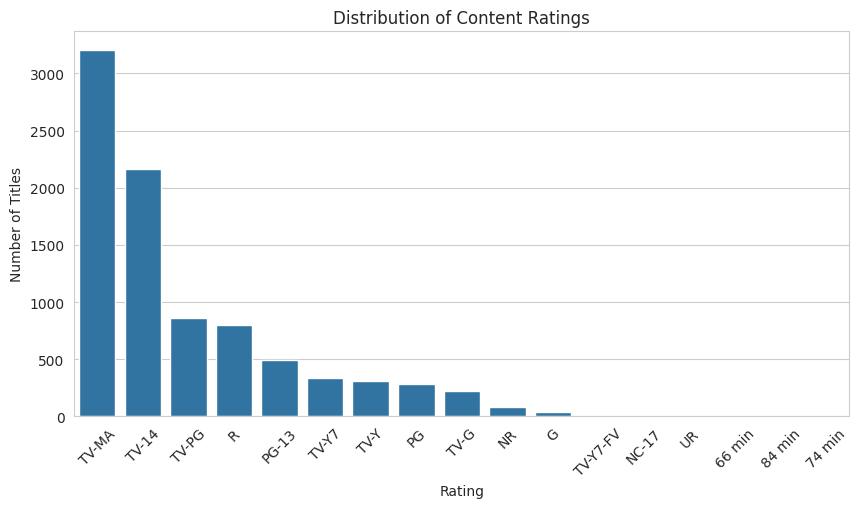

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='rating', data=df,order=df['rating'].value_counts().index)
plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

This visually confirms the TV-MA/TV-14 dominance we found earlier.

In [ ]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


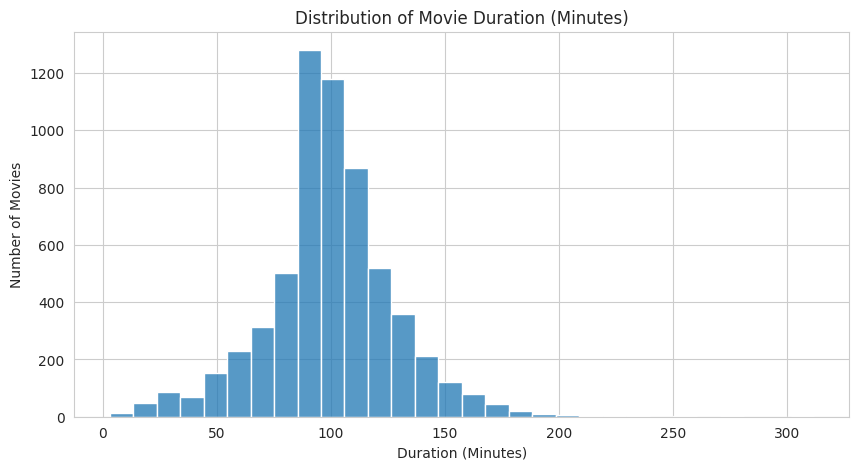

In [ ]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_mins'] = movies['duration'].str.replace(' min', '').astype(float)

plt.figure(figsize=(10,5))
sns.histplot(movies['duration_mins'], bins=30)
plt.title('Distribution of Movie Duration (Minutes)')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')
plt.show()

The vast majority of movies falling between 80-120 minutes, peaking sharply around the 90-100 minute mark. This aligns with typical industry-standard feature film length. There's a long thin tail beyond 150 minutes, representing a smaller number of longer films, and very few movies run under 40 minutes or beyond 200 minutes — indicating Netflix's movie catalog largely conforms to conventional runtime expectations rather than skewing toward unusually short or long films.

### 4.2 Bivariate Analysis

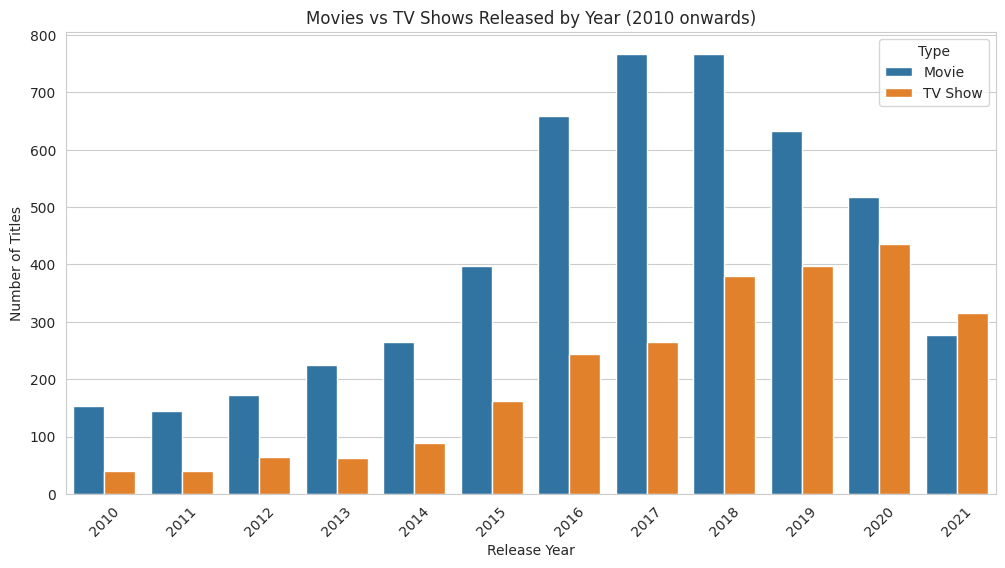

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='release_year', hue='type', data=df[df['release_year'] >= 2010])
plt.title('Movies vs TV Shows Released by Year (2010 onwards)')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.show()

While movies consistently outnumbered TV shows every year from 2010-2021, the gap has narrowed dramatically over time. In 2010, movies outnumbered shows by roughly 4x; by 2021, the two are nearly equal, with TV shows (316) actually surpassing movies (277) for the first time. Movie releases also peaked around 2017-2018 and have declined since, while TV show releases have grown steadily throughout the period. This strongly suggests Netflix has been deliberately shifting its content strategy toward TV shows in recent years — likely because serialized content drives longer subscriber engagement and retention compared to standalone movies.

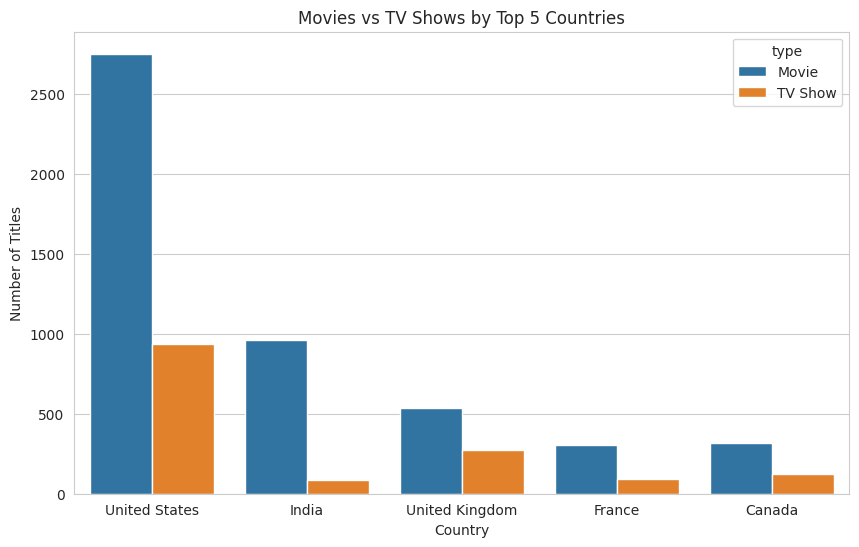

In [ ]:
top5_countries = df_country['country'].value_counts().head(5).index
country_type=df_country[df_country['country'].isin(top5_countries)]

plt.figure(figsize=(10,6))
sns.countplot(x='country', hue='type', data=country_type)
plt.title('Movies vs TV Shows by Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.show()

Comparing movie vs TV show output across the top 5 producing countries reveals a clear pattern: the United States has the most balanced ratio, producing a meaningful volume of both movies and TV shows. India, however, is overwhelmingly movie-focused — with roughly 960 movies but under 100 TV shows, a far more skewed ratio than any other top country. The UK, France, and Canada all show relatively low absolute volumes but lean more toward movies than shows as well. This suggests India's contribution to Netflix is driven almost entirely by its film industry (likely reflecting Bollywood's dominance), while the US content strategy is more evenly split between films and serialized shows — consistent with the earlier finding that Netflix has been growing its TV show catalog primarily through its US-driven push.

## 5. Missing Value & Outlier Check

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
director,2634
country,831
cast,825
date_added,98
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


Revisiting missing values: director (2,634 missing, ~30%) and cast (825, ~9%) are the largest gaps — likely because Netflix's metadata for older or less prominent titles is incomplete, or because documentaries/stand-up specials often don't have a traditional 'director' credit in the same way. country (831, ~9%) is missing where production origin wasn't recorded. Given the scale of missing director data, dropping those rows would remove nearly a third of the dataset — instead, we treat missing values as 'Unknown' rather than deleting them, since we're still analyzing type, genre, ratings, and other fields for those rows regardless. date_added, rating, and duration have negligible missing counts (under 10 rows each) and can be safely dropped without meaningfully affecting the analysis.

In [ ]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df = df.dropna(subset=['date_added', 'rating', 'duration'])

In [ ]:
df.shape

(8702, 12)

After filling director, cast, and country with 'Unknown' (rather than dropping them, since that would remove ~30% of the data), and dropping rows with missing date_added, rating, or duration (which were negligible), the dataset now has 8,702 rows — a loss of only 105 rows (1.2%). This confirms the missing value treatment preserved almost all the original data while removing the small number of genuinely unusable rows.

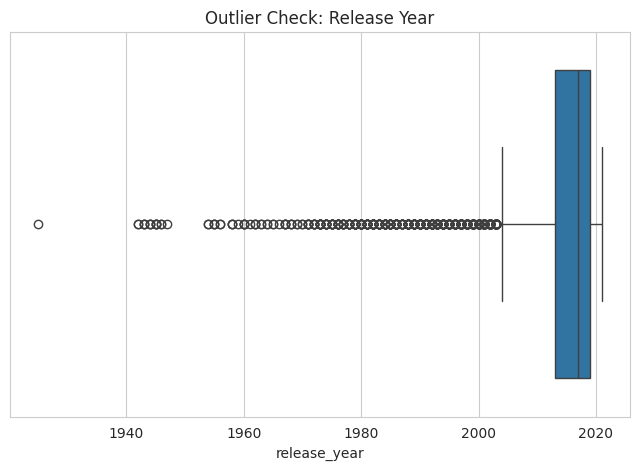

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['release_year'])
plt.title('Outlier Check: Release Year')
plt.show()

The boxplot confirms that most content clusters tightly between roughly 2013-2021, with the box (interquartile range) sitting entirely in this recent window. Every title released before ~2005 is flagged as a statistical outlier (shown as individual dots), including the earliest title from 1925. This doesn't mean these are 'bad' data points — they're legitimately old titles Netflix has licensed — but statistically, they're rare enough to be outliers relative to the bulk of the catalog. Given this reflects real catalog composition rather than data errors, we choose not to remove these outliers, since they represent genuine older content Netflix offers rather than mistakes.

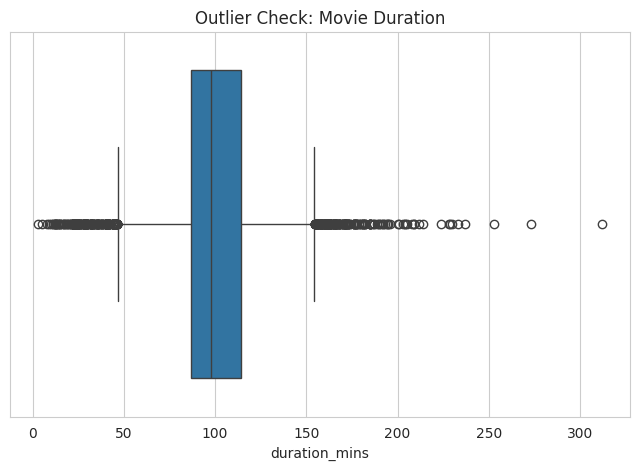

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=movies['duration_mins'])
plt.title('Outlier Check: Movie Duration')
plt.show()

Movie duration shows outliers on both ends: several very short movies (under ~45 minutes) and a handful of very long ones (up to ~312 minutes). The bulk of movies fall between roughly 90-115 minutes, consistent with the earlier histogram. The short-duration outliers likely correspond to comedy specials, short films, or documentaries — content types that don't follow standard feature-length conventions. The long-duration outliers (250+ minutes) are likely rare titles like extended director's cuts or multi-part epics. As with release year, these outliers reflect genuine catalog diversity rather than data errors, so they're kept in the analysis rather than removed.

In [ ]:
movies[movies['duration_mins'] < 40][['title', 'listed_in', 'duration_mins']].head(10)

,title,listed_in,duration_mins
45,My Heroes Were Cowboys,Documentaries,23.0
71,A StoryBots Space Adventure,Children & Family Movies,13.0
470,Bridgerton - The Afterparty,Movies,39.0
495,Awon Boyz,"Documentaries, International Movies",38.0
560,Audible,"Documentaries, Sports Movies",39.0
694,Aziza,"Comedies, Dramas, Independent Movies",13.0
695,Besieged Bread,"Dramas, International Movies",12.0
729,Bling Empire - The Afterparty,Movies,36.0
730,Cobra Kai - The Afterparty,Movies,34.0
732,To All the Boys: Always and Forever - The Afte...,Movies,36.0


## 6. Insights based on Non-Graphical and Visual Analysis

### 6.1 Range of Attributes

Release_year ranges from 1925 to 2021, though the vast majority of content falls between 2013-2021. Movie duration ranges from as short as a few minutes (specials/short films) to over 300 minutes (rare long-form content), with a typical range of 90-120 minutes. rating spans 17 categories, dominated by TV-MA and TV-14. Content spans 748 raw country entries (reducible to fewer after splitting multi-country listings) and comes from over 4,500 unique directors.

### 6.2 Distribution & Relationships

Content type is imbalanced (~70% movies, 30% TV shows), though this ratio has been narrowing sharply since 2015, with TV shows nearly matching movies by 2021 — indicating a clear strategic shift. Release year is heavily right-skewed toward recent years. Movie duration is roughly normally distributed around 90-110 minutes. Country and genre fields are highly concentrated at the top (US and India dominate country; International Movies and Dramas dominate genre) with a long tail of smaller categories.

### 6.3 Plot-by-Plot Comments


- Release year histogram: confirmed heavy skew toward 2015-2021.
- Type countplot: confirmed 70:30 movie/TV split.
- Genre bar chart: International Movies and Dramas lead.
- Country bar chart: US and India dominate.
- Movie/TV trend by year: revealed narrowing gap over time — key finding.
- Country vs type: revealed India is movie-heavy while US is more balanced — key finding.
- Duration histogram/boxplot: confirmed standard 90-120 min runtime with some outliers.

## 7. Business Insights

**1. Netflix is shifting from movies to TV shows.** While movies still dominate the overall catalog (70%), the yearly release trend shows this gap has nearly closed by 2021, with TV shows almost matching movie releases. This points to a deliberate strategic pivot — likely because serialized shows keep subscribers engaged (and subscribed) longer than one-time movie watches.

**2. The US and India are Netflix's two content powerhouses, but with very different profiles.** The US drives volume across both movies and TV shows fairly evenly, while India's contribution is almost entirely movie-driven (likely Bollywood-influenced), with very few Indian TV shows. This is a gap — Netflix may be under-investing in Indian-origin TV series despite India being its #2 content-producing country.

**3. Content skews toward mature audiences.** TV-MA and TV-14 together account for roughly 60% of the catalog, while family/children's content (TV-Y, TV-G, PG) is comparatively underrepresented. This suggests Netflix's core content strategy targets adult and teen viewers over younger audiences.

**4. International content is a major, deliberate strategy — not an afterthought.** "International Movies" and "International TV Shows" are among the top genre categories, and combined with the country diversity (India, UK, Japan, South Korea, Spain all in the top 10), this confirms Netflix has invested heavily in global content rather than relying solely on US-produced shows.

**5. Genre focus is concentrated in a few categories.** Dramas, Comedies, and International content dominate; niche categories like children's content and romance make up a smaller share, suggesting room for diversification if Netflix wants to capture underserved audience segments."

## 8. Recommendations

**1. Continue investing in TV shows, not just movies.** Since TV shows are catching up with movies in recent years,Netflix should keep putting more budget on series with multiple seasons so that viewers can binge watch that.

**2. Expand TV show production in India specifically.** India is Netflix second largest content market,but almost all market is movie driven and very few TV shows are there so Netflix should focus more on TV shows in India.

**3. Grow the family and children's content library.** With TV-MA and TV-14 dominating the catalog,Netflix has very less content for younger generation.Netflix should expand more in the kids and family programmes which will help in gathering family audience as well.

**4. Keep doubling down on international content.** Given the strong performance of international genres and countries beyond the US, Netflix should continue producing and licensing region-specific content (like it has with Korean and Spanish shows), since this appears to be a deliberate and successful strategy already.

**5. Diversify beyond the current top-heavy genres.** Since Dramas, Comedies, and International content dominate, Netflix could explore investing more in currently smaller categories (romance, children's content, documentaries) to capture niche audiences not fully served by the current catalog mix.